In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

In [2]:
from google.colab import files

uploaded = files.upload()

Saving agriculture_yield_dataset.csv to agriculture_yield_dataset (1).csv


In [3]:
df = pd.read_csv("agriculture_yield_dataset (1).csv")
df.head()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17


In [4]:
##Q1 Dataset Overview

print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 10 Records:")
display(df.head(10))

Rows and Columns: (1500, 8)

Column Names:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']

First 10 Records:


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


In [5]:
##Q2 Data Types and Missing Values

print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing Values:
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64


In [6]:
##Q3 Descriptive Statistics

stats = df.describe()
display(stats)

print("Highest Mean:")
print(stats.loc['mean'].idxmax())

print("Highest Standard Deviation:")
print(stats.loc['std'].idxmax())

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,754.054667,27.749467,148.744067,5.403267,6.759133,5.028793
std,255.097216,5.758101,56.990279,2.584329,0.719742,0.968282
min,300.200000,18.000000,50.300000,1.000000,5.500000,2.090000
25%,536.175000,22.600000,98.600000,3.200000,6.100000,4.337500
50%,761.200000,27.700000,146.850000,5.400000,6.800000,5.010000
75%,964.375000,32.600000,196.575000,7.600000,7.400000,5.740000
max,1200.000000,38.000000,249.900000,10.000000,8.000000,7.860000


Highest Mean:
rainfall_mm
Highest Standard Deviation:
rainfall_mm


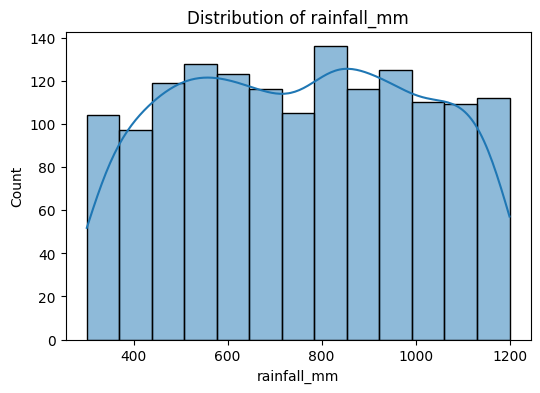

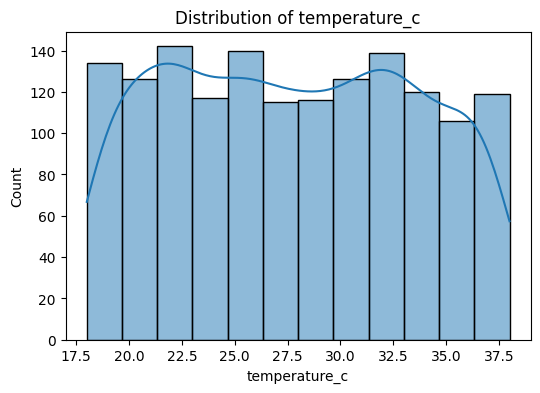

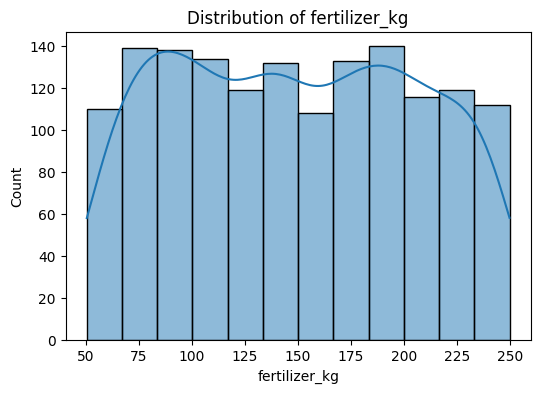

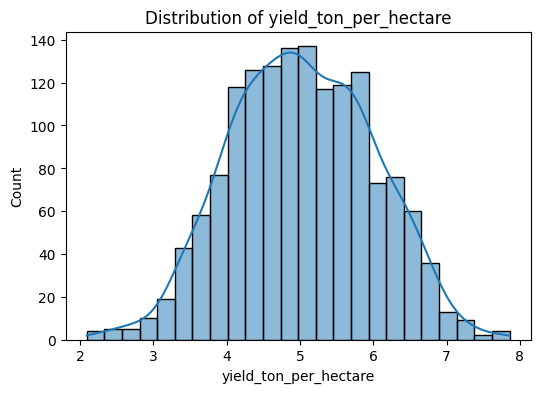

In [7]:
##Q4 Distribution Analysis

columns = [
    'rainfall_mm',
    'temperature_c',
    'fertilizer_kg',
    'yield_ton_per_hectare'
]
for col in columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


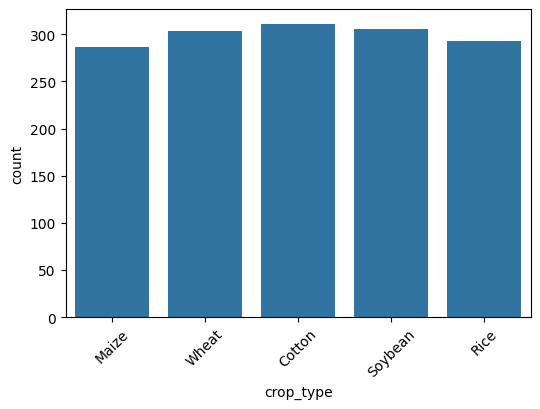

Most Frequent Crop:
Cotton


In [8]:
##Q5 Crop Type Analysis

crop_count = df['crop_type'].value_counts()

print(crop_count)

plt.figure(figsize=(6,4))
sns.countplot(x='crop_type', data=df)
plt.xticks(rotation=45)
plt.show()

print("Most Frequent Crop:")
print(crop_count.idxmax())

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


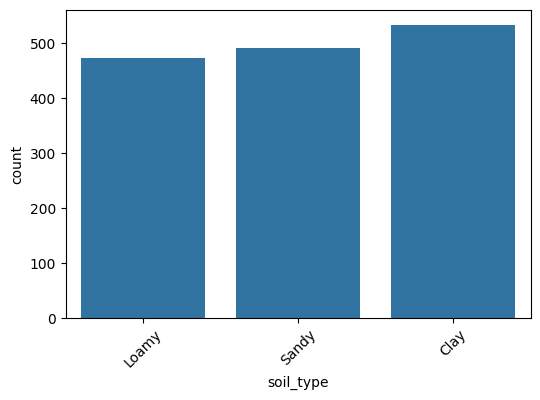

Most Common Soil:
Clay


In [9]:
##Q6 Soil Type Analysis

soil_count = df['soil_type'].value_counts()

print(soil_count)

plt.figure(figsize=(6,4))
sns.countplot(x='soil_type', data=df)
plt.xticks(rotation=45)
plt.show()

print("Most Common Soil:")
print(soil_count.idxmax())

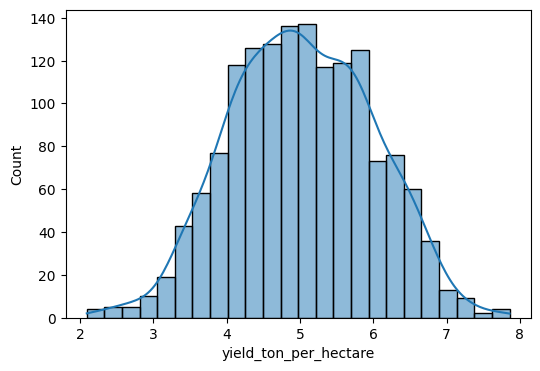

In [10]:
##Q7 Yield Distribution

plt.figure(figsize=(6,4))
sns.histplot(df['yield_ton_per_hectare'], kde=True)
plt.show()

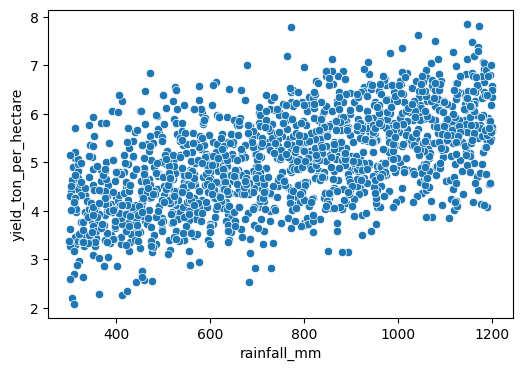

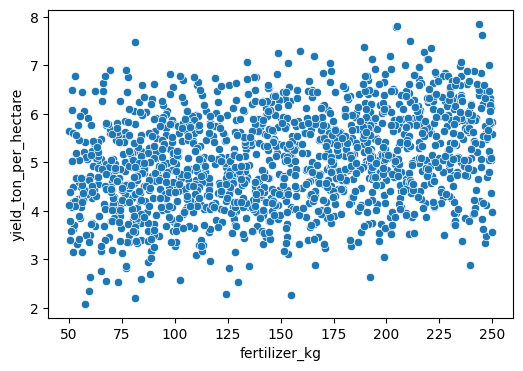

In [11]:
##Q8 Scatter Plot Analysis

plt.figure(figsize=(6,4))
sns.scatterplot(
    x='rainfall_mm',
    y='yield_ton_per_hectare',
    data=df
)
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(
    x='fertilizer_kg',
    y='yield_ton_per_hectare',
    data=df
)
plt.show()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
rainfall_mm,1.000000,0.026721,0.002558,0.010877,0.006916,0.553704
temperature_c,0.026721,1.000000,0.037468,0.007114,0.001513,-0.022559
fertilizer_kg,0.002558,0.037468,1.000000,-0.010497,0.010001,0.278043
irrigation_hours,0.010877,0.007114,-0.010497,1.000000,0.009307,0.542664
soil_ph,0.006916,0.001513,0.010001,0.009307,1.000000,0.024412
yield_ton_per_hectare,0.553704,-0.022559,0.278043,0.542664,0.024412,1.000000


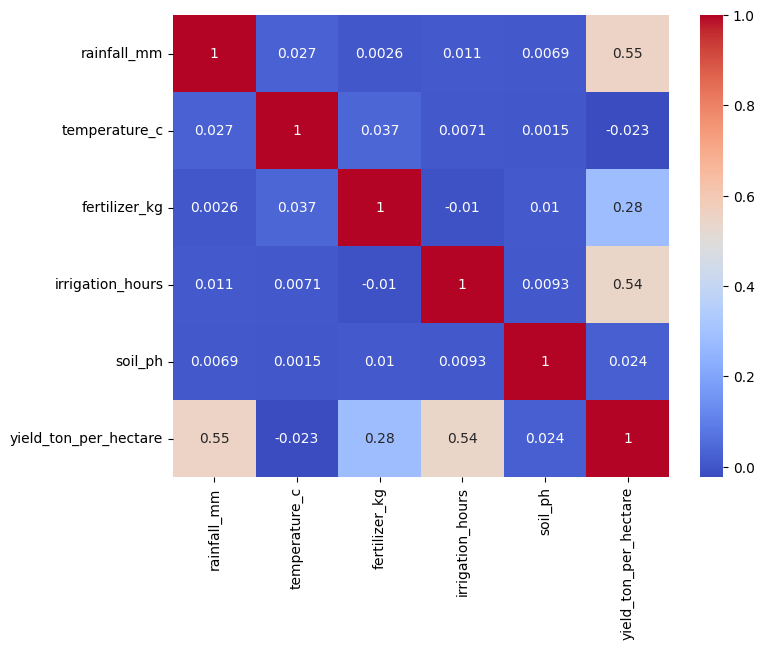

yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
soil_ph                  0.024412
temperature_c           -0.022559
Name: yield_ton_per_hectare, dtype: float64


In [12]:
##Q9 Correlation Analysis

corr = df.corr(numeric_only=True)

display(corr)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

corr_target = corr['yield_ton_per_hectare'].sort_values(ascending=False)

print(corr_target)

In [13]:
##Q10 Group Based Analysis

crop_avg = df.groupby('crop_type')['yield_ton_per_hectare'].mean()

soil_avg = df.groupby('soil_type')['yield_ton_per_hectare'].mean()

print(crop_avg)
print()
print(soil_avg)

print("\nHighest Yield Crop:")
print(crop_avg.idxmax())

print("\nHighest Yield Soil:")
print(soil_avg.idxmax())

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64

soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

Highest Yield Crop:
Rice

Highest Yield Soil:
Loamy


In [14]:
##Q11 One Hot Encoding

categorical_cols = df.select_dtypes(include='object').columns

print(categorical_cols)

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

display(df_encoded.head())

Index(['crop_type', 'soil_type'], dtype='object')


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,True,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,True,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,True,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,True,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,False,False,False,False,False,False


In [15]:
##Q12 Feature Selection

X = df_encoded.drop(
    'yield_ton_per_hectare',
    axis=1
)

y = df_encoded['yield_ton_per_hectare']

print("Target Variable:")
print(y.name)

Target Variable:
yield_ton_per_hectare


In [16]:
##Q13 Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1200, 11)
X_test : (300, 11)
y_train: (1200,)
y_test : (300,)


In [17]:
##Q14 Linear Regression

model = LinearRegression()

model.fit(X_train, y_train)

print("Intercept:")
print(model.intercept_)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

display(coef_df)

print("\nHighest Positive Coefficient:")

print(
    coef_df.loc[
        coef_df['Coefficient'].idxmax()
    ]
)

Intercept:
1.587132027736121


,Feature,Coefficient
0,rainfall_mm,0.002035
1,temperature_c,-0.009175
2,fertilizer_kg,0.004978
3,irrigation_hours,0.198327
4,soil_ph,0.004901
5,crop_type_Maize,0.238931
6,crop_type_Rice,0.863993
7,crop_type_Soybean,0.481719
8,crop_type_Wheat,0.348474
9,soil_type_Loamy,0.302974



Highest Positive Coefficient:
Feature        crop_type_Rice
Coefficient          0.863993
Name: 6, dtype: object
